# CELL 1 — Install dependencies

In [127]:
!pip -q install kagglehub xgboost

# CELL 2 — Imports

In [128]:
import os
import re
import ast
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

# CELL 3 — Download the Kaggle dataset

In [66]:
import kagglehub

path = kagglehub.dataset_download(
    "derrickmwiti/google-2019-cluster-sample"
)

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'google-2019-cluster-sample' dataset.
Dataset downloaded to:
/kaggle/input/google-2019-cluster-sample


# CELL 4 — Find the CSV automatically

In [67]:
csv_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")

for f in csv_files:
    print(f)

CSV files found:
/kaggle/input/google-2019-cluster-sample/borg_traces_data.csv


# CELL 5 — Load dataset

In [68]:
csv_path = [
    f for f in csv_files
    if "borg_traces_data.csv" in f
][0]

df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (405894, 34)


,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,resource_request,constraint,collections_events_type,user,collection_name,collection_logical_name,start_after_collection_ids,vertical_scaling,scheduler,start_time,end_time,average_usage,maximum_usage,random_sample_usage,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,"{'cpus': 0.020660400390625, 'memory': 0.014434...",[],2,fn8Ve4Tdl/FVVvwXFGIKe4+Wo4zLjUL/557qdFVYu5M=,Hzsv/gF8CPQXdqpsfovDTC1TJNyphDxPu7vaTeNxA74=,YCuhYrnORLiUh9WGL5q5tkBevfwtucSnFr2qPZh6Kes=,[],1.0,0.0,274800000000,275100000000,"{'cpus': 0.00466156005859375, 'memory': 0.0059...","{'cpus': 0.01190185546875, 'memory': 0.0059356...","{'cpus': 0.0043487548828125, 'memory': None}",0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,"{'cpus': 0.00724029541015625, 'memory': 0.0013...",[],2,DrrEIEWkWuW7RrZwpHLCN0k0A2J0usJeyt3wtqzZ7Kk=,hDGffcrF/rhQQEG8Uns/RMUK7R15DXjFnRasoKFhefI=,wcRcAMuop2OqH9EW4feH919tadFec5a11ply0hcS/C8=,[],2.0,0.0,1800713000000,1800714000000,"{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': None}",0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,"{'cpus': 0.048583984375, 'memory': 0.004165649...",[],6,/ivQBmewiFcXfGJdCUsEKx47NiRE29Tjiq3gw+zR2Cg=,kk6+maA6fvAdJ+VTU8AcpzQPTyVrx+ySt0MXRAyO8FU=,zCA2dl2PDptd82Hob906gE82JHzx0SbqA4mZurqZdmY=,[],2.0,1.0,81300000000,81600000000,"{'cpus': 0.024200439453125, 'memory': 0.002788...","{'cpus': 0.06005859375, 'memory': 0.0028457641...","{'cpus': 0.026458740234375, 'memory': None}",0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,"{'cpus': 0.0704345703125, 'memory': 0.04162597...",[],2,8qRmTJas/6XEBaA0l4Wt1+/qSLgc6p7u7JzoMSuT/M8=,fypwFjdqaQPSxCfeqVPCBAvFcnntmkRpQxwQ/vJsCxU=,uNjMQD1+DL9IgCFckx8lHOsCbyvLgKmZCmRjiyWZNhk=,[],2.0,0.0,1075500000000,1075800000000,"{'cpus': 0.047607421875, 'memory': 0.034423828...","{'cpus': 0.13330078125, 'memory': 0.03466796875}","{'cpus': 0.05084228515625, 'memory': None}",0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,"{'cpus': 0.00244903564453125, 'memory': 0.0002...",[],3,+cz+wEXttqDjld+YWLmrgqExjdqiHMZ2WZODThyR9jE=,WS2kraTQdfsFtOIepw9SIo7ETi2ag8uwy7gt2MrpIe0=,VJ0ExwthLLpbqbyOA77EoNypzEiPYg3mECxUve0GCnY=,[],3.0,0.0,1565315000000,1565317000000,"{'cpus': 0.000270843505859375, 'memory': 7.629...","{'cpus': 0.00041484832763671875, 'memory': 7.6...","{'cpus': 0.0003414154052734375, 'memory': None}",0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


# CELL 6 — Dataset information

In [69]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumn names:")
for col in df.columns:
    print(col)

Rows: 405894
Columns: 34

Column names:
Unnamed: 0
time
instance_events_type
collection_id
scheduling_class
collection_type
priority
alloc_collection_id
instance_index
machine_id
resource_request
constraint
collections_events_type
user
collection_name
collection_logical_name
start_after_collection_ids
vertical_scaling
scheduler
start_time
end_time
average_usage
maximum_usage
random_sample_usage
assigned_memory
page_cache_memory
cycles_per_instruction
memory_accesses_per_instruction
sample_rate
cpu_usage_distribution
tail_cpu_usage_distribution
cluster
event
failed


# CELL 7 — Basic dataset inspection

In [70]:
display(
    pd.DataFrame({
        "dtype": df.dtypes,
        "missing": df.isna().sum(),
        "unique": df.nunique()
    }).sort_values("missing", ascending=False)
)

,dtype,missing,unique
memory_accesses_per_instruction,float64,124688,3418
cycles_per_instruction,float64,124688,3417
vertical_scaling,float64,959,3
scheduler,float64,959,2
resource_request,object,774,21900
Unnamed: 0,int64,0,405894
time,int64,0,334354
priority,int64,0,22
instance_events_type,int64,0,10
collection_id,int64,0,4057


# CELL 8 — Failure distribution

In [71]:
print("Failure distribution:")

display(
    df["failed"].value_counts().to_frame("count")
)

print("\nFailure percentage:")

display(
    (df["failed"].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame("percentage")
)

Failure distribution:


,count
failed,
0,313216
1,92678



Failure percentage:


,percentage
failed,
0,77.17
1,22.83


# CELL 9 — Remove unnecessary columns

In [72]:
remove_cols = [
    "Unnamed: 0",
    "collection_name",
    "collection_logical_name",
    "start_after_collection_ids",
    "constraint",
    "random_sample_usage"
]

df = df.drop(
    columns=remove_cols,
    errors="ignore"
)

print("Shape after removing unnecessary columns:", df.shape)

Shape after removing unnecessary columns: (405894, 28)


# CELL 10 — Parse numerical/dictionary columns

In [73]:
def parse_dict_or_number(val):

    if pd.isna(val):
        return 0.0

    if isinstance(val, (int, float, np.number)):
        return float(val)

    if isinstance(val, str):

        val = val.strip()

        try:

            if val.startswith("{") and val.endswith("}"):

                d = ast.literal_eval(val)

                nums = []

                for v in d.values():

                    try:
                        nums.append(float(v))
                    except:
                        pass

                if len(nums) > 0:
                    return float(np.mean(nums))

                return 0.0

            return float(val)

        except:
            return 0.0

    return 0.0

# CELL 11 — Apply numerical parsing

In [74]:
dict_like_cols = [
    "average_usage",
    "maximum_usage",
    "assigned_memory",
    "page_cache_memory",
    "cycles_per_instruction",
    "memory_accesses_per_instruction"
]

for col in dict_like_cols:

    if col in df.columns:

        df[col] = df[col].apply(
            parse_dict_or_number
        )

print("Numerical parsing complete.")

Numerical parsing complete.


# CELL 12 — Parse CPU distributions

In [75]:
def parse_distribution(val):

    if pd.isna(val):
        return 0.0

    if isinstance(val, (int, float, np.number)):
        return float(val)

    if isinstance(val, str):

        try:

            nums = re.findall(
                r'[-+]?(?:\d*\.\d+|\d+\.?\d*)(?:[eE][-+]?\d+)?',
                val
            )

            nums = np.array(nums, dtype=float)

            if len(nums) == 0:
                return 0.0

            return float(np.mean(nums))

        except:
            return 0.0

    return 0.0

# CELL 13 — Apply distribution parser

In [76]:
for col in [
    "cpu_usage_distribution",
    "tail_cpu_usage_distribution"
]:

    if col in df.columns:

        df[col] = df[col].apply(
            parse_distribution
        )

print("Distribution parsing complete.")

Distribution parsing complete.


# CELL 14 — Sort by time

In [77]:
df = df.sort_values(
    "time"
).reset_index(drop=True)

print("Dataset sorted chronologically.")

Dataset sorted chronologically.


# CELL 15 — IMPORTANT: inspect timestamp intervals

In [78]:
time_diff = df["time"].diff()

print("Time difference statistics:")
display(time_diff.describe())

Time difference statistics:


,time
count,4.058930e+05
mean,2.272365e+13
std,1.447717e+16
min,0.000000e+00
25%,2.000000e+01
50%,8.223810e+05
75%,7.131489e+06
max,9.223369e+18


In [79]:
print("\nMost common time intervals:")

display(
    time_diff.value_counts().head(20)
)


Most common time intervals:


,count
time,
0.0,71540
5.0,6639
2.0,5379
10.0,3861
8.0,3669
3.0,1628
20.0,1345
9.0,1213
16.0,1193


# CELL 16 — Convert time to seconds

In [80]:
df["time_seconds"] = df["time"] / 1_000_000

print(
    "Time range:",
    df["time_seconds"].min(),
    "to",
    df["time_seconds"].max(),
    "seconds"
)

Time range: 0.0 to 9223372036854.775 seconds


# CELL 17 — Basic workload features

In [81]:
df["cpu"] = df["average_usage"]

df["memory"] = df["assigned_memory"]

df["max_cpu"] = df["maximum_usage"]

df["cache_memory"] = df["page_cache_memory"]

# CELL 18 — CPU and memory changes

In [82]:
df["cpu_change"] = df["cpu"].diff()

df["memory_change"] = df["memory"].diff()

df["max_cpu_change"] = df["max_cpu"].diff()

# CELL 19 — Rolling workload statistics

In [83]:
WINDOW = 10

df["cpu_roll_mean"] = (
    df["cpu"]
    .rolling(WINDOW)
    .mean()
)

df["memory_roll_mean"] = (
    df["memory"]
    .rolling(WINDOW)
    .mean()
)

df["cpu_roll_std"] = (
    df["cpu"]
    .rolling(WINDOW)
    .std()
)

df["memory_roll_std"] = (
    df["memory"]
    .rolling(WINDOW)
    .std()
)

# CELL 20 — Workload acceleration

In [84]:
df["cpu_acceleration"] = (
    df["cpu_change"].diff()
)

df["memory_acceleration"] = (
    df["memory_change"].diff()
)

# CELL 21 — Lag features

In [85]:
for lag in [1, 2, 3, 5, 10]:

    df[f"cpu_lag_{lag}"] = (
        df["cpu"].shift(lag)
    )

    df[f"memory_lag_{lag}"] = (
        df["memory"].shift(lag)
    )

    df[f"failure_lag_{lag}"] = (
        df["failed"].shift(lag)
    )

# CELL 22 — Remove invalid rows

In [86]:
df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.fillna(0)

print("Shape after feature engineering:", df.shape)

Shape after feature engineering: (405894, 57)


# CELL 23 — Create future failure targets

In [87]:
def future_failure(series, horizon):

    values = series.to_numpy()

    result = np.zeros(len(values))

    for i in range(len(values)):

        start = i + 1
        end = min(
            i + horizon + 1,
            len(values)
        )

        if start < end:

            result[i] = (
                values[start:end].max()
            )

    return result

# CELL 24 — Create failure targets

In [88]:
HORIZONS = {
    "5min": 1,
    "30min": 6,
    "1hr": 12,
    "2hr": 24
}

for name, step in HORIZONS.items():

    df[f"failure_{name}"] = future_failure(
        df["failed"],
        step
    )

# CELL 25 — Create future CPU/memory targets

In [89]:
for name, step in HORIZONS.items():

    df[f"future_cpu_{name}"] = (
        df["cpu"].shift(-step)
    )

    df[f"future_memory_{name}"] = (
        df["memory"].shift(-step)
    )

# CELL 26 — Remove future NaNs

In [90]:
df = df.dropna().reset_index(drop=True)

print("Final modeling dataset:", df.shape)

Final modeling dataset: (405870, 69)


# CELL 27 — Feature list

In [91]:
numeric_features = [

    "cpu",
    "memory",
    "max_cpu",
    "cache_memory",

    "cycles_per_instruction",
    "memory_accesses_per_instruction",

    "cpu_change",
    "memory_change",
    "max_cpu_change",

    "cpu_roll_mean",
    "memory_roll_mean",

    "cpu_roll_std",
    "memory_roll_std",

    "cpu_acceleration",
    "memory_acceleration",

    "priority",
    "instance_index",

    "cpu_lag_1",
    "cpu_lag_2",
    "cpu_lag_3",
    "cpu_lag_5",
    "cpu_lag_10",

    "memory_lag_1",
    "memory_lag_2",
    "memory_lag_3",
    "memory_lag_5",
    "memory_lag_10",

    "failure_lag_1",
    "failure_lag_2",
    "failure_lag_3",
    "failure_lag_5",
    "failure_lag_10"
]

In [92]:
categorical_features = [
    "instance_events_type",
    "scheduling_class",
    "cluster",
    "event"
]

# CELL 28 — Prepare X

In [93]:
X = df[
    numeric_features +
    categorical_features
].copy()

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=False
)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (405870, 64)


# CELL 29 — Select 30-minute failure target

In [94]:
y_failure = df["failure_30min"].astype(int)

print("Target distribution:")

display(
    y_failure.value_counts()
)

Target distribution:


,count
failure_30min,
1,233625
0,172245


# CELL 30 — Chronological train/validation/test split

In [95]:
n = len(X)

train_end = int(n * 0.70)

val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y_failure.iloc[:train_end]
y_val = y_failure.iloc[train_end:val_end]
y_test = y_failure.iloc[val_end:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (284109, 64)
Validation: (60880, 64)
Test: (60881, 64)


# CELL 31 — Calculate class imbalance

In [96]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / max(positive, 1)

print("Negative:", negative)
print("Positive:", positive)
print("Scale pos weight:", scale_pos_weight)

Negative: 122942
Positive: 161167
Scale pos weight: 0.7628236549665874


# CELL 32 — Train XGBoost failure predictor

In [97]:
failure_model = XGBClassifier(

    n_estimators=400,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="logloss",

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    n_jobs=-1
)

print("Training failure prediction model...")

failure_model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_val, y_val)
    ],

    verbose=False
)

print("Training complete.")

Training failure prediction model...
Training complete.


# CELL 33 — Predict failure probability

In [98]:
failure_probability = (
    failure_model
    .predict_proba(X_test)[:, 1]
)

failure_prediction = (
    failure_probability >= 0.5
).astype(int)

# CELL 34 — Failure model metrics

In [99]:
accuracy = accuracy_score(
    y_test,
    failure_prediction
)

precision = precision_score(
    y_test,
    failure_prediction,
    zero_division=0
)

recall = recall_score(
    y_test,
    failure_prediction,
    zero_division=0
)

f1 = f1_score(
    y_test,
    failure_prediction,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    failure_probability
)

pr_auc = average_precision_score(
    y_test,
    failure_probability
)

print(" CLOUD FAILURE MODEL PERFORMANCE")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

 CLOUD FAILURE MODEL PERFORMANCE
Accuracy : 0.7892
Precision: 0.8019
Recall   : 0.8481
F1 Score : 0.8243
ROC-AUC  : 0.8533
PR-AUC   : 0.8592


# CELL 35 — Classification report

In [100]:
print(
    classification_report(
        y_test,
        failure_prediction,
        target_names=[
            "No Failure",
            "Failure"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  No Failure       0.77      0.71      0.74     25375
     Failure       0.80      0.85      0.82     35506

    accuracy                           0.79     60881
   macro avg       0.79      0.78      0.78     60881
weighted avg       0.79      0.79      0.79     60881



# CELL 36 — Confusion matrix graph

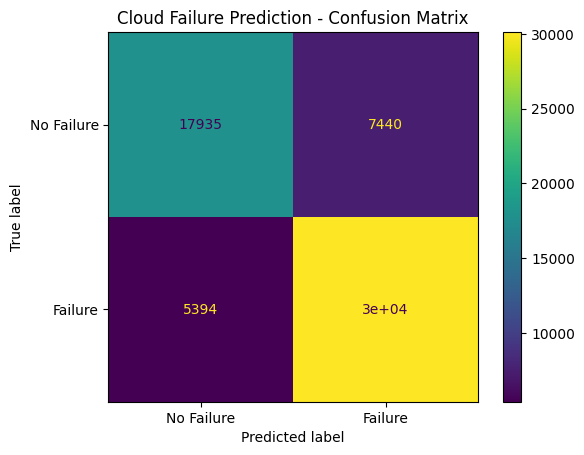

In [101]:
cm = confusion_matrix(
    y_test,
    failure_prediction
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Failure",
        "Failure"
    ]
)

disp.plot()

plt.title(
    "Cloud Failure Prediction - Confusion Matrix"
)

plt.show()

# CELL 37 — ROC curve

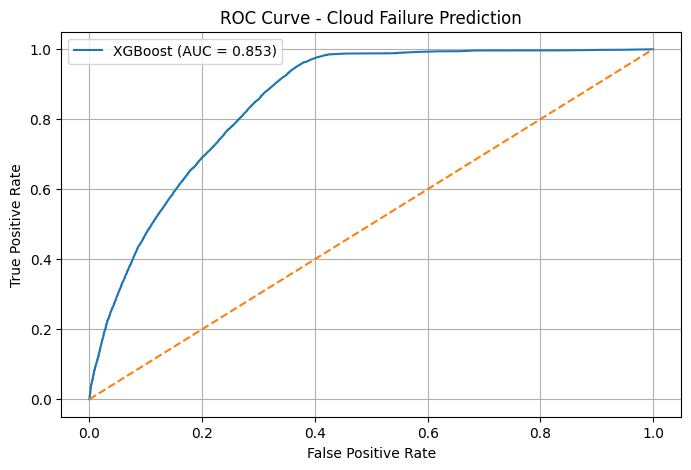

In [102]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    failure_probability
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Cloud Failure Prediction"
)

plt.legend()

plt.grid(True)

plt.show()

# CELL 38 — Precision-Recall curve

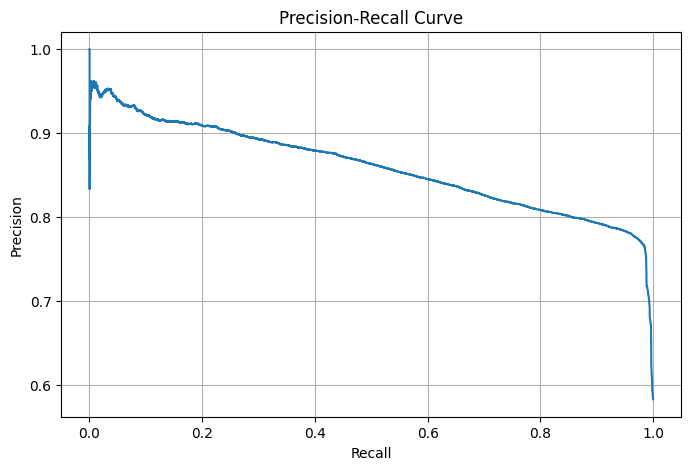

In [103]:
precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        failure_probability
    )
)

plt.figure(figsize=(8, 5))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve"
)

plt.grid(True)

plt.show()

# CELL 39 — Feature importance

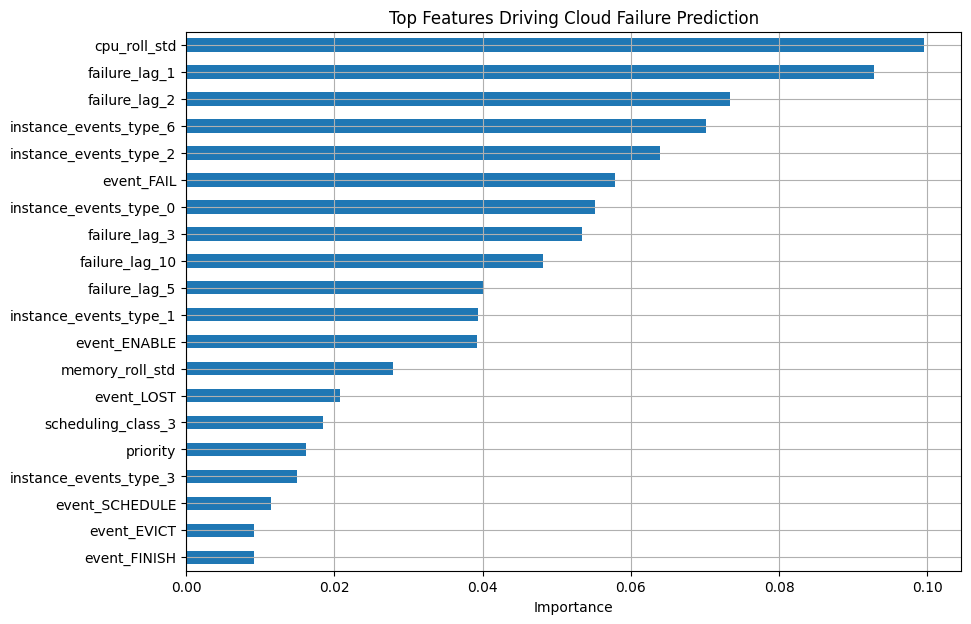

In [104]:
importance = pd.Series(
    failure_model.feature_importances_,
    index=X_train.columns
)

importance = (
    importance
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 7))

importance.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")

plt.title(
    "Top Features Driving Cloud Failure Prediction"
)

plt.grid(True)

plt.show()

# CELL 40 — Resource forecasting model

In [105]:
y_cpu = df["future_cpu_30min"]

X_cpu = X.copy()

X_cpu_train = X_cpu.iloc[:train_end]
X_cpu_val = X_cpu.iloc[train_end:val_end]
X_cpu_test = X_cpu.iloc[val_end:]

y_cpu_train = y_cpu.iloc[:train_end]
y_cpu_val = y_cpu.iloc[train_end:val_end]
y_cpu_test = y_cpu.iloc[val_end:]

# CELL 41 — Train CPU model

In [106]:
cpu_model = XGBRegressor(

    n_estimators=400,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1
)

print("Training CPU forecasting model...")

cpu_model.fit(
    X_cpu_train,
    y_cpu_train,

    eval_set=[
        (X_cpu_val, y_cpu_val)
    ],

    verbose=False
)

print("CPU model trained.")

Training CPU forecasting model...
CPU model trained.


# CELL 42 — CPU prediction

In [107]:
cpu_prediction = cpu_model.predict(
    X_cpu_test
)

cpu_mae = mean_absolute_error(
    y_cpu_test,
    cpu_prediction
)

cpu_rmse = np.sqrt(
    mean_squared_error(
        y_cpu_test,
        cpu_prediction
    )
)

cpu_r2 = r2_score(
    y_cpu_test,
    cpu_prediction
)

print(" CPU FORECASTING PERFORMANCE")

print(f"MAE :  {cpu_mae:.6f}")
print(f"RMSE:  {cpu_rmse:.6f}")
print(f"R²  :  {cpu_r2:.6f}")

 CPU FORECASTING PERFORMANCE
MAE :  0.005426
RMSE:  0.012073
R²  :  0.351011


# CELL 43 — CPU forecast graph

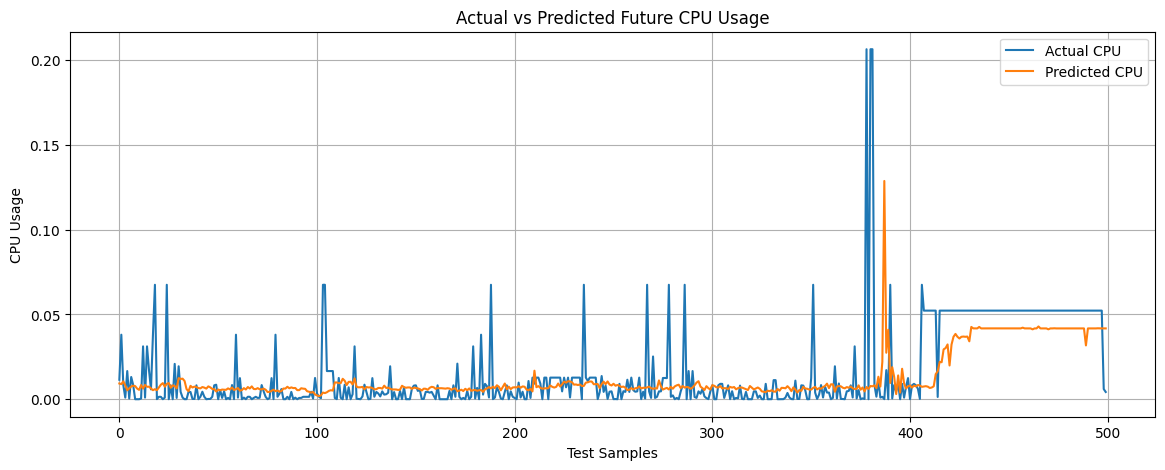

In [108]:
sample_size = min(
    500,
    len(y_cpu_test)
)

plt.figure(figsize=(14, 5))

plt.plot(
    y_cpu_test.iloc[:sample_size].values,
    label="Actual CPU"
)

plt.plot(
    cpu_prediction[:sample_size],
    label="Predicted CPU"
)

plt.xlabel("Test Samples")

plt.ylabel("CPU Usage")

plt.title(
    "Actual vs Predicted Future CPU Usage"
)

plt.legend()

plt.grid(True)

plt.show()

# CELL 44 — Memory forecasting model

In [109]:
y_memory = df["future_memory_30min"]

X_mem_train = X.iloc[:train_end]
X_mem_val = X.iloc[train_end:val_end]
X_mem_test = X.iloc[val_end:]

y_mem_train = y_memory.iloc[:train_end]
y_mem_val = y_memory.iloc[train_end:val_end]
y_mem_test = y_memory.iloc[val_end:]

# CELL 45 — Train memory model

In [110]:
memory_model = XGBRegressor(

    n_estimators=400,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1
)

print("Training memory forecasting model...")

memory_model.fit(
    X_mem_train,
    y_mem_train,

    eval_set=[
        (X_mem_val, y_mem_val)
    ],

    verbose=False
)

print("Memory model trained.")

Training memory forecasting model...
Memory model trained.


# CELL 46 — Memory evaluation

In [111]:
memory_prediction = (
    memory_model.predict(X_mem_test)
)

memory_mae = mean_absolute_error(
    y_mem_test,
    memory_prediction
)

memory_rmse = np.sqrt(
    mean_squared_error(
        y_mem_test,
        memory_prediction
    )
)

memory_r2 = r2_score(
    y_mem_test,
    memory_prediction
)

print("================================")
print(" MEMORY FORECASTING PERFORMANCE")
print("================================")

print(f"MAE :  {memory_mae:.6f}")
print(f"RMSE:  {memory_rmse:.6f}")
print(f"R²  :  {memory_r2:.6f}")

 MEMORY FORECASTING PERFORMANCE
MAE :  0.009191
RMSE:  0.025916
R²  :  0.293577


# CELL 47 — Memory forecast graph

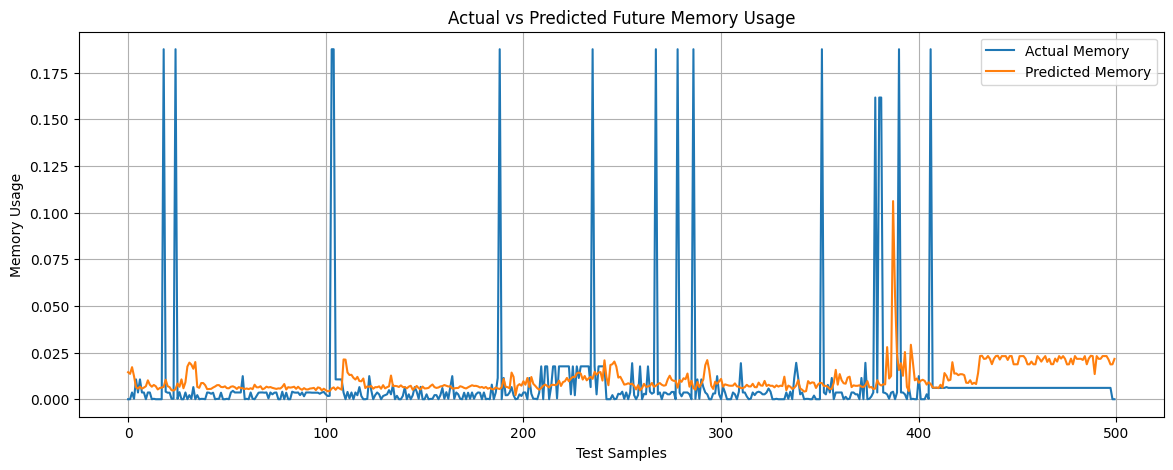

In [112]:
sample_size = min(
    500,
    len(y_mem_test)
)

plt.figure(figsize=(14, 5))

plt.plot(
    y_mem_test.iloc[:sample_size].values,
    label="Actual Memory"
)

plt.plot(
    memory_prediction[:sample_size],
    label="Predicted Memory"
)

plt.xlabel("Test Samples")

plt.ylabel("Memory Usage")

plt.title(
    "Actual vs Predicted Future Memory Usage"
)

plt.legend()

plt.grid(True)

plt.show()

# CELL 48 — Actual vs predicted failure probabilities

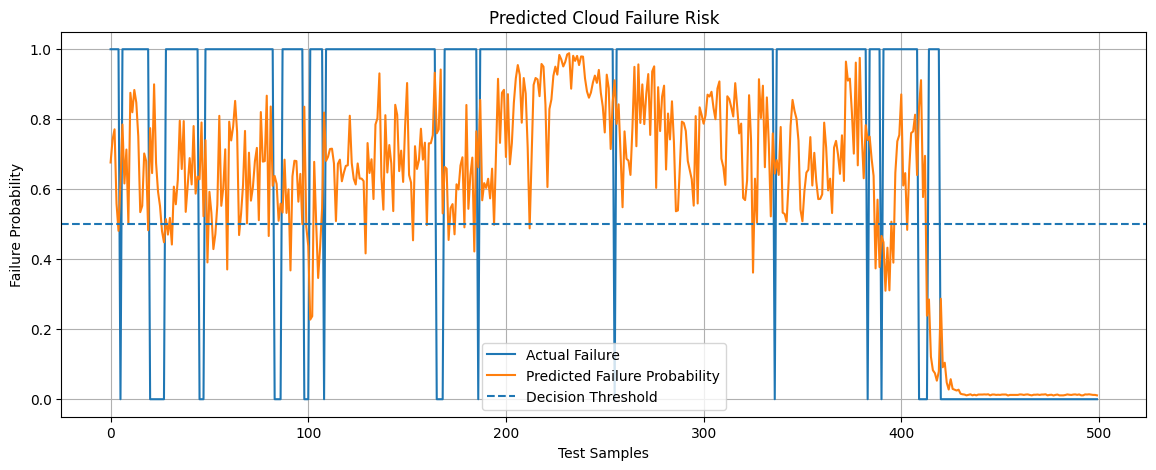

In [113]:
sample_size = min(
    500,
    len(y_test)
)

plt.figure(figsize=(14, 5))

plt.plot(
    y_test.iloc[:sample_size].values,
    label="Actual Failure"
)

plt.plot(
    failure_probability[:sample_size],
    label="Predicted Failure Probability"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Decision Threshold"
)

plt.xlabel("Test Samples")

plt.ylabel("Failure Probability")

plt.title(
    "Predicted Cloud Failure Risk"
)

plt.legend()

plt.grid(True)

plt.show()

# CELL 49 — Create cloud health score

In [114]:
def calculate_health_score(
    failure_probability,
    predicted_cpu,
    predicted_memory
):

    failure_risk = failure_probability * 100

    cpu_risk = min(
        predicted_cpu / 0.90,
        1
    ) * 100

    memory_risk = min(
        predicted_memory / 0.90,
        1
    ) * 100

    risk = max(
        failure_risk,
        cpu_risk,
        memory_risk
    )

    health = max(
        0,
        100 - risk
    )

    return health

# CELL 50 — Scaling recommendation engine

In [115]:
def scaling_decision(
    failure_probability,
    predicted_cpu,
    predicted_memory
):

    if (
        failure_probability >= 0.70
        or predicted_cpu >= 0.85
        or predicted_memory >= 0.85
    ):

        pressure = max(
            predicted_cpu,
            predicted_memory
        )

        if pressure >= 0.95:
            nodes = "+3 nodes"

        elif pressure >= 0.85:
            nodes = "+2 nodes"

        else:
            nodes = "+1 node"

        return "SCALE UP", nodes

    elif (
        failure_probability <= 0.10
        and predicted_cpu <= 0.30
        and predicted_memory <= 0.30
    ):

        return "SCALE DOWN", "-1 node"

    else:

        return "MAINTAIN", "No change"

# CELL 51 — Generate recommendations for test data

In [116]:
recommendations = []

for fp, cpu_pred, mem_pred in zip(
    failure_probability,
    cpu_prediction,
    memory_prediction
):

    action, nodes = scaling_decision(
        fp,
        cpu_pred,
        mem_pred
    )

    health = calculate_health_score(
        fp,
        cpu_pred,
        mem_pred
    )

    recommendations.append({

        "Failure Probability": fp,

        "Predicted CPU": cpu_pred,

        "Predicted Memory": mem_pred,

        "Health Score": health,

        "Recommendation": action,

        "Capacity Change": nodes
    })

results = pd.DataFrame(
    recommendations
)

display(results.head(20))

,Failure Probability,Predicted CPU,Predicted Memory,Health Score,Recommendation,Capacity Change
0,0.676397,0.009289,0.014469,32.360336,MAINTAIN,No change
1,0.741690,0.008911,0.013592,25.830986,SCALE UP,+1 node
2,0.771149,0.010553,0.017176,22.885063,SCALE UP,+1 node
3,0.558981,0.008124,0.012323,44.101898,MAINTAIN,No change
4,0.481088,0.005277,0.006429,51.891209,MAINTAIN,No change
5,0.620129,0.006455,0.005673,37.987106,MAINTAIN,No change
6,0.784993,0.007545,0.006751,21.500740,SCALE UP,+1 node
7,0.616381,0.007970,0.005670,38.361908,MAINTAIN,No change
8,0.713353,0.007756,0.006229,28.664688,SCALE UP,+1 node
9,0.500756,0.006275,0.006954,49.924366,MAINTAIN,No change


# CELL 52 — Risk categories

In [117]:
def risk_category(probability):

    if probability >= 0.70:
        return "HIGH"

    elif probability >= 0.40:
        return "MEDIUM"

    else:
        return "LOW"


results["Risk Level"] = (
    results["Failure Probability"]
    .apply(risk_category)
)

display(
    results.head(20)
)

,Failure Probability,Predicted CPU,Predicted Memory,Health Score,Recommendation,Capacity Change,Risk Level
0,0.676397,0.009289,0.014469,32.360336,MAINTAIN,No change,MEDIUM
1,0.741690,0.008911,0.013592,25.830986,SCALE UP,+1 node,HIGH
2,0.771149,0.010553,0.017176,22.885063,SCALE UP,+1 node,HIGH
3,0.558981,0.008124,0.012323,44.101898,MAINTAIN,No change,MEDIUM
4,0.481088,0.005277,0.006429,51.891209,MAINTAIN,No change,MEDIUM
5,0.620129,0.006455,0.005673,37.987106,MAINTAIN,No change,MEDIUM
6,0.784993,0.007545,0.006751,21.500740,SCALE UP,+1 node,HIGH
7,0.616381,0.007970,0.005670,38.361908,MAINTAIN,No change,MEDIUM
8,0.713353,0.007756,0.006229,28.664688,SCALE UP,+1 node,HIGH
9,0.500756,0.006275,0.006954,49.924366,MAINTAIN,No change,MEDIUM


# CELL 53 — Distribution of recommendations

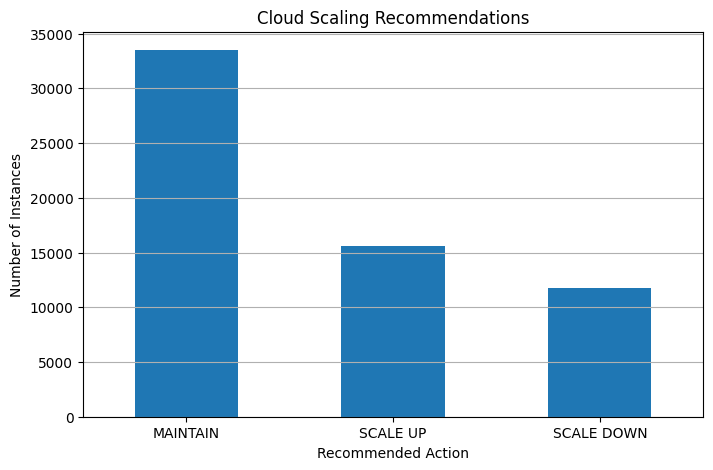

In [118]:
recommendation_counts = (
    results["Recommendation"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

recommendation_counts.plot(
    kind="bar"
)

plt.xlabel("Recommended Action")

plt.ylabel("Number of Instances")

plt.title(
    "Cloud Scaling Recommendations"
)

plt.xticks(rotation=0)

plt.grid(
    axis="y"
)

plt.show()

# CELL 54 — Risk distribution

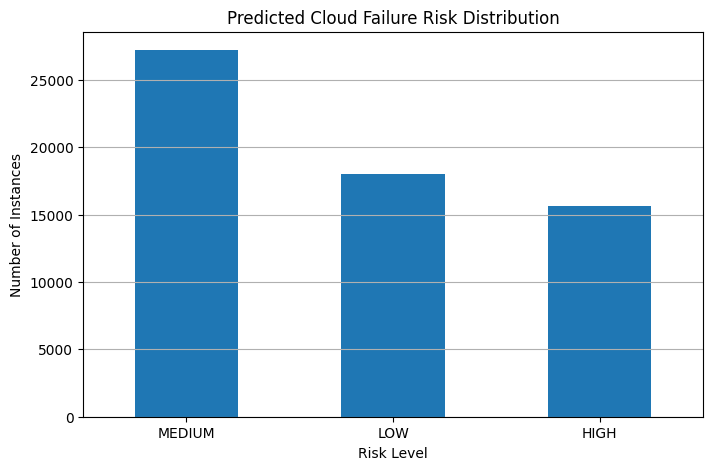

In [119]:
risk_counts = (
    results["Risk Level"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

risk_counts.plot(
    kind="bar"
)

plt.xlabel("Risk Level")

plt.ylabel("Number of Instances")

plt.title(
    "Predicted Cloud Failure Risk Distribution"
)

plt.xticks(rotation=0)

plt.grid(
    axis="y"
)

plt.show()

# CELL 55 — CPU vs memory resource pressure

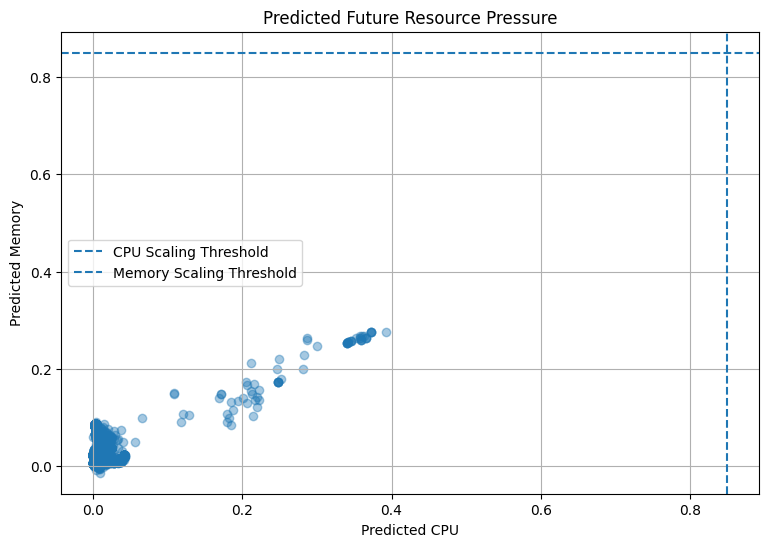

In [120]:
plt.figure(figsize=(9, 6))

plt.scatter(
    results["Predicted CPU"],
    results["Predicted Memory"],
    alpha=0.4
)

plt.axvline(
    0.85,
    linestyle="--",
    label="CPU Scaling Threshold"
)

plt.axhline(
    0.85,
    linestyle="--",
    label="Memory Scaling Threshold"
)

plt.xlabel(
    "Predicted CPU"
)

plt.ylabel(
    "Predicted Memory"
)

plt.title(
    "Predicted Future Resource Pressure"
)

plt.legend()

plt.grid(True)

plt.show()

# CELL 56 — Cloud health score distribution

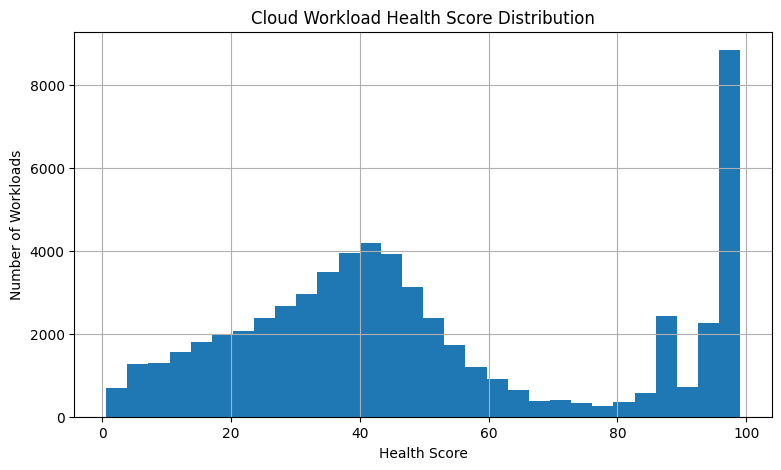

In [121]:
plt.figure(figsize=(9, 5))

plt.hist(
    results["Health Score"],
    bins=30
)

plt.xlabel("Health Score")

plt.ylabel("Number of Workloads")

plt.title(
    "Cloud Workload Health Score Distribution"
)

plt.grid(True)

plt.show()

# CELL 57 — Show high-risk workloads

In [122]:
high_risk = (
    results[
        results["Risk Level"] == "HIGH"
    ]
    .sort_values(
        "Failure Probability",
        ascending=False
    )
)

display(
    high_risk.head(20)
)

,Failure Probability,Predicted CPU,Predicted Memory,Health Score,Recommendation,Capacity Change,Risk Level
42733,0.993810,0.008656,0.011259,0.619011,SCALE UP,+1 node,HIGH
7707,0.992648,0.006935,0.007895,0.735176,SCALE UP,+1 node,HIGH
51804,0.990842,0.007399,0.007288,0.915840,SCALE UP,+1 node,HIGH
8004,0.989434,0.006215,0.007912,1.056641,SCALE UP,+1 node,HIGH
232,0.988626,0.008373,0.010130,1.137421,SCALE UP,+1 node,HIGH
5239,0.988209,0.005498,0.009363,1.179085,SCALE UP,+1 node,HIGH
14544,0.988024,0.007065,0.008312,1.197617,SCALE UP,+1 node,HIGH
42222,0.987716,0.007451,0.007300,1.228424,SCALE UP,+1 node,HIGH
14798,0.987346,0.006657,0.006832,1.265404,SCALE UP,+1 node,HIGH
15462,0.987179,0.007179,0.006684,1.282074,SCALE UP,+1 node,HIGH


# CELL 58 — Create a single workload prediction function

In [123]:
def predict_cloud_health(row):

    input_data = row[
        numeric_features +
        categorical_features
    ].copy()

    input_df = pd.DataFrame(
        [input_data]
    )

    input_df = pd.get_dummies(
        input_df,
        columns=categorical_features,
        drop_first=False
    )

    input_df = input_df.reindex(
        columns=X.columns,
        fill_value=0
    )

    failure_prob = (
        failure_model
        .predict_proba(input_df)[0, 1]
    )

    future_cpu = (
        cpu_model
        .predict(input_df)[0]
    )

    future_memory = (
        memory_model
        .predict(input_df)[0]
    )

    action, capacity = scaling_decision(
        failure_prob,
        future_cpu,
        future_memory
    )

    health = calculate_health_score(
        failure_prob,
        future_cpu,
        future_memory
    )

    return {
        "Failure Probability": failure_prob,
        "Predicted CPU": future_cpu,
        "Predicted Memory": future_memory,
        "Health Score": health,
        "Risk Level": risk_category(failure_prob),
        "Recommendation": action,
        "Capacity Change": capacity
    }

# CELL 59 — Test the system

In [124]:
sample_index = df.index[-100]

sample = df.loc[
    sample_index
]

prediction = predict_cloud_health(
    sample
)

print("      CLOUD RESOURCE HEALTH REPORT")

print(
    f"Failure Probability : "
    f"{prediction['Failure Probability']:.2%}"
)

print(
    f"Predicted CPU       : "
    f"{prediction['Predicted CPU']:.4f}"
)

print(
    f"Predicted Memory    : "
    f"{prediction['Predicted Memory']:.4f}"
)

print(
    f"Health Score        : "
    f"{prediction['Health Score']:.1f}/100"
)

print(
    f"Risk Level          : "
    f"{prediction['Risk Level']}"
)

print(
    f"Recommendation      : "
    f"{prediction['Recommendation']}"
)

print(
    f"Capacity Change     : "
    f"{prediction['Capacity Change']}"
)

      CLOUD RESOURCE HEALTH REPORT
Failure Probability : 68.68%
Predicted CPU       : 0.0063
Predicted Memory    : 0.0056
Health Score        : 31.3/100
Risk Level          : MEDIUM
Recommendation      : MAINTAIN
Capacity Change     : No change


# CELL 60 — Save models

In [125]:
joblib.dump(
    failure_model,
    "cloud_failure_model.pkl"
)

joblib.dump(
    cpu_model,
    "cpu_forecasting_model.pkl"
)

joblib.dump(
    memory_model,
    "memory_forecasting_model.pkl"
)

joblib.dump(
    list(X.columns),
    "feature_columns.pkl"
)

print("Models saved successfully.")

Models saved successfully.


# CELL 61 — Final model summary

In [131]:
print("      CLOUD RESOURCE INTELLIGENCE SYSTEM")

print("\nFAILURE PREDICTION")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nCPU FORECASTING")
print(f"MAE : {cpu_mae:.6f}")
print(f"RMSE: {cpu_rmse:.6f}")
print(f"R²  : {cpu_r2:.6f}")

print("\nMEMORY FORECASTING")
print(f"MAE : {memory_mae:.6f}")
print(f"RMSE: {memory_rmse:.6f}")
print(f"R²  : {memory_r2:.6f}")



      CLOUD RESOURCE INTELLIGENCE SYSTEM

FAILURE PREDICTION
Accuracy : 0.7892
Precision: 0.8019
Recall   : 0.8481
F1 Score : 0.8243
ROC-AUC  : 0.8533
PR-AUC   : 0.8592

CPU FORECASTING
MAE : 0.005426
RMSE: 0.012073
R²  : 0.351011

MEMORY FORECASTING
MAE : 0.009191
RMSE: 0.025916
R²  : 0.293577
